# 03 - EDA and Feature Engineering

**Objective:** Explore Breast Cancer data patterns and create new features.

**Steps:**
1. Statistical summary and class distribution
2. Visualizations (distributions, correlations, feature comparison by diagnosis)
3. Feature scaling
4. Feature engineering (interaction and ratio features)
5. Save engineered data

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
PROCESSED_DIR = Path("../data/processed")

df = pd.read_csv(PROCESSED_DIR / "clean_data.csv")
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Diagnosis               569 non-null    int64  
 1   Mean_Radius             569 non-null    float64
 2   SE_Radius               569 non-null    float64
 3   Worst_Radius            569 non-null    float64
 4   Mean_Texture            569 non-null    float64
 5   SE_Texture              569 non-null    float64
 6   Worst_Texture           569 non-null    float64
 7   Mean_Perimeter          569 non-null    float64
 8   SE_Perimeter            569 non-null    float64
 9   Worst_Perimeter         569 non-null    float64
 10  Mean_Area               569 non-null    float64
 11  SE_Area                 569 non-null    float64
 12  Worst_Area              569 non-null    float64
 13  Mean_Smoothness         569 non-null    float64
 14  SE_Smoothness           569 non-null    fl

### Statistical Summary & Distribution

Before building any models, it is important to understand the range and spread of your data.
The target variable — `Diagnosis` — is binary (a classification problem).
Check the class balance to see if the dataset is imbalanced, which might affect model evaluation.

Breast cancer data has 30 features grouped into three categories:
- **Mean_** (10 features): average measurements of cell nuclei
- **SE_** (10 features): standard error of measurements
- **Worst_** (10 features): largest (worst) measurements

In [3]:
print("Class distribution (Diagnosis):")
print(df["Diagnosis"].value_counts())
print("\nFeature summary statistics:")
print(df.describe())

Class distribution (Diagnosis):
Diagnosis
0    357
1    212
Name: count, dtype: int64

Feature summary statistics:
        Diagnosis  Mean_Radius   SE_Radius  Worst_Radius  Mean_Texture  \
count  569.000000   569.000000  569.000000    569.000000    569.000000   
mean     0.372583    14.127292   19.289649     91.969033    654.889104   
std      0.483918     3.524049    4.301036     24.298981    351.914129   
min      0.000000     6.981000    9.710000     43.790000    143.500000   
25%      0.000000    11.700000   16.170000     75.170000    420.300000   
50%      0.000000    13.370000   18.840000     86.240000    551.100000   
75%      1.000000    15.780000   21.800000    104.100000    782.700000   
max      1.000000    28.110000   39.280000    188.500000   2501.000000   

       SE_Texture  Worst_Texture  Mean_Perimeter  SE_Perimeter  \
count  569.000000     569.000000      569.000000    569.000000   
mean     0.096360       0.104341        0.088799      0.048919   
std      0.014064   

#### A little primer on groupby 

- `groupby` is a powerful pandas method that allows you to split your data into groups based on some criteria, apply a function to each group, and then combine the results. For example, to see how measurements differ between benign and malignant tumors, you can do:

```python
mean_by_diagnosis = df.groupby("Diagnosis")["Mean_Radius"].mean()
```

- `aggregate` is a method that allows you to apply multiple functions to your grouped data. For example, to get both the mean and standard deviation of Mean_Radius by Diagnosis, you can do:

```python
stats_by_diagnosis = df.groupby("Diagnosis")["Mean_Radius"].aggregate(["mean", "std"])
```

Aggregate functions can be any function that takes a Series and returns a single value, such as `mean`, `std`, `min`, `max`, etc.
Aggregate can be deployed on multiple columns at once, and you can specify different functions for each column if needed.

In [4]:
# === Executed Example: GroupBy and Aggregate ===
# Small inline dataset showing how groupby splits data by Diagnosis
# and compares average measurements between classes.

import pandas as pd

data = pd.DataFrame({
    "Diagnosis": [0, 0, 0, 1, 1, 1],
    "Mean_Radius": [12.0, 13.5, 11.8, 17.2, 18.5, 16.9],
    "Mean_Texture": [18.5, 20.2, 17.1, 21.4, 22.0, 20.8],
})

mean_by_diag = data.groupby("Diagnosis")["Mean_Radius"].mean()
print("Average Mean_Radius by Diagnosis:\n", mean_by_diag)

stats_by_diag = data.groupby("Diagnosis")["Mean_Texture"].agg(["mean", "std", "min", "max"])
print("\nTexture statistics by Diagnosis:\n", stats_by_diag)

Average Mean_Radius by Diagnosis:
 Diagnosis
0    12.433333
1    17.533333
Name: Mean_Radius, dtype: float64

Texture statistics by Diagnosis:
            mean       std   min   max
Diagnosis                            
0          18.6  1.552417  17.1  20.2
1          21.4  0.600000  20.8  22.0


In [5]:
# === Commented Template: GroupBy and Aggregate ===
# Uncomment and adapt to your own dataset.

# import pandas as pd
# data = pd.DataFrame({
#     "group_col": [val1, val1, val2, val2],
#     "value_col": [10, 20, 30, 40],
# })
# grouped = data.groupby("group_col")["value_col"].mean()
#     stats = data.groupby("group_col")["value_col"].agg(["mean", "std", "min", "max"])

### Missing Value Imputation

Our clean data has no missing values, but the corrupted variants from
`data_injection/` do. Common strategies:

- **Drop rows**: `df.dropna()` — fast, loses samples
- **Mean/Median imputation**: `SimpleImputer(strategy='median')` — preserves sample count
- **KNN imputation**: `KNNImputer()` — estimates from neighbors, more robust
- **Forward fill**: `df.ffill()` — for sequential data

In [6]:
from sklearn.impute import SimpleImputer

# Simulate missing values on a copy
df_test = df.copy()
df_test.loc[:5, 'Mean_Radius'] = np.nan
print(f"Before: {df_test['Mean_Radius'].isna().sum()} NaNs")

imputer = SimpleImputer(strategy='mean')
df_test['Mean_Radius'] = imputer.fit_transform(df_test[['Mean_Radius']])
print(f"After: {df_test['Mean_Radius'].isna().sum()} NaNs")
print(f"Imputed value (mean): {imputer.statistics_[0]:.3f}")

Before: 6 NaNs
After: 0 NaNs
Imputed value (mean): 14.096


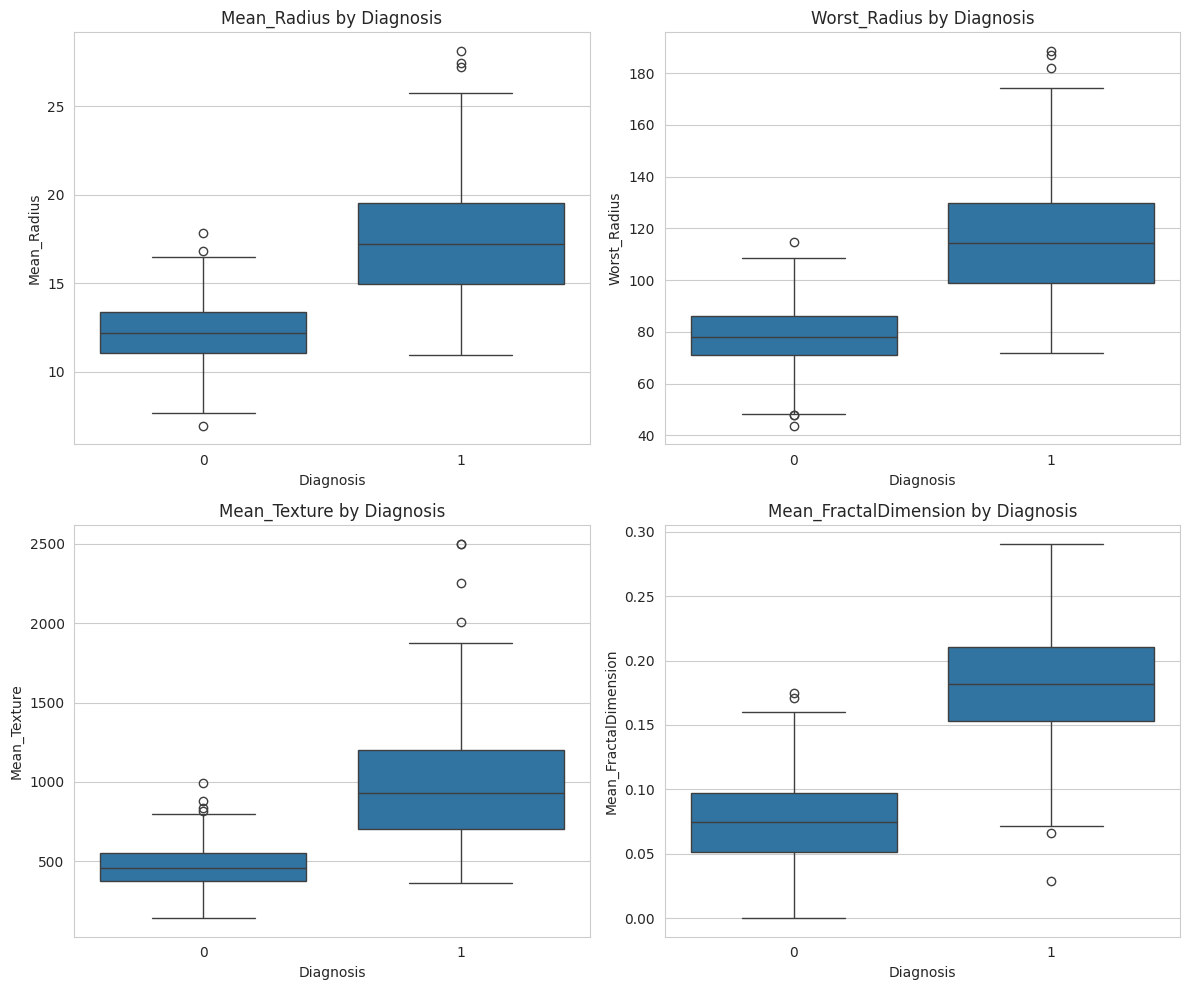

In [ ]:
features_to_plot = ["Mean_Radius", "Worst_Radius", "Mean_Texture", "Mean_FractalDimension"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feature in zip(axes.ravel(), features_to_plot):
    sns.boxplot(x="Diagnosis", y=feature, data=df, ax=ax)
    ax.set_title(f"{feature} by Diagnosis")
plt.tight_layout()
plt.show()

### Visualizations

Visual exploration helps you spot patterns and relationships that summary statistics miss.
Focus on:
- How each feature is distributed (histograms)
- How features correlate with each other and with the target (heatmap)
- Which features separate benign from malignant (boxplots)

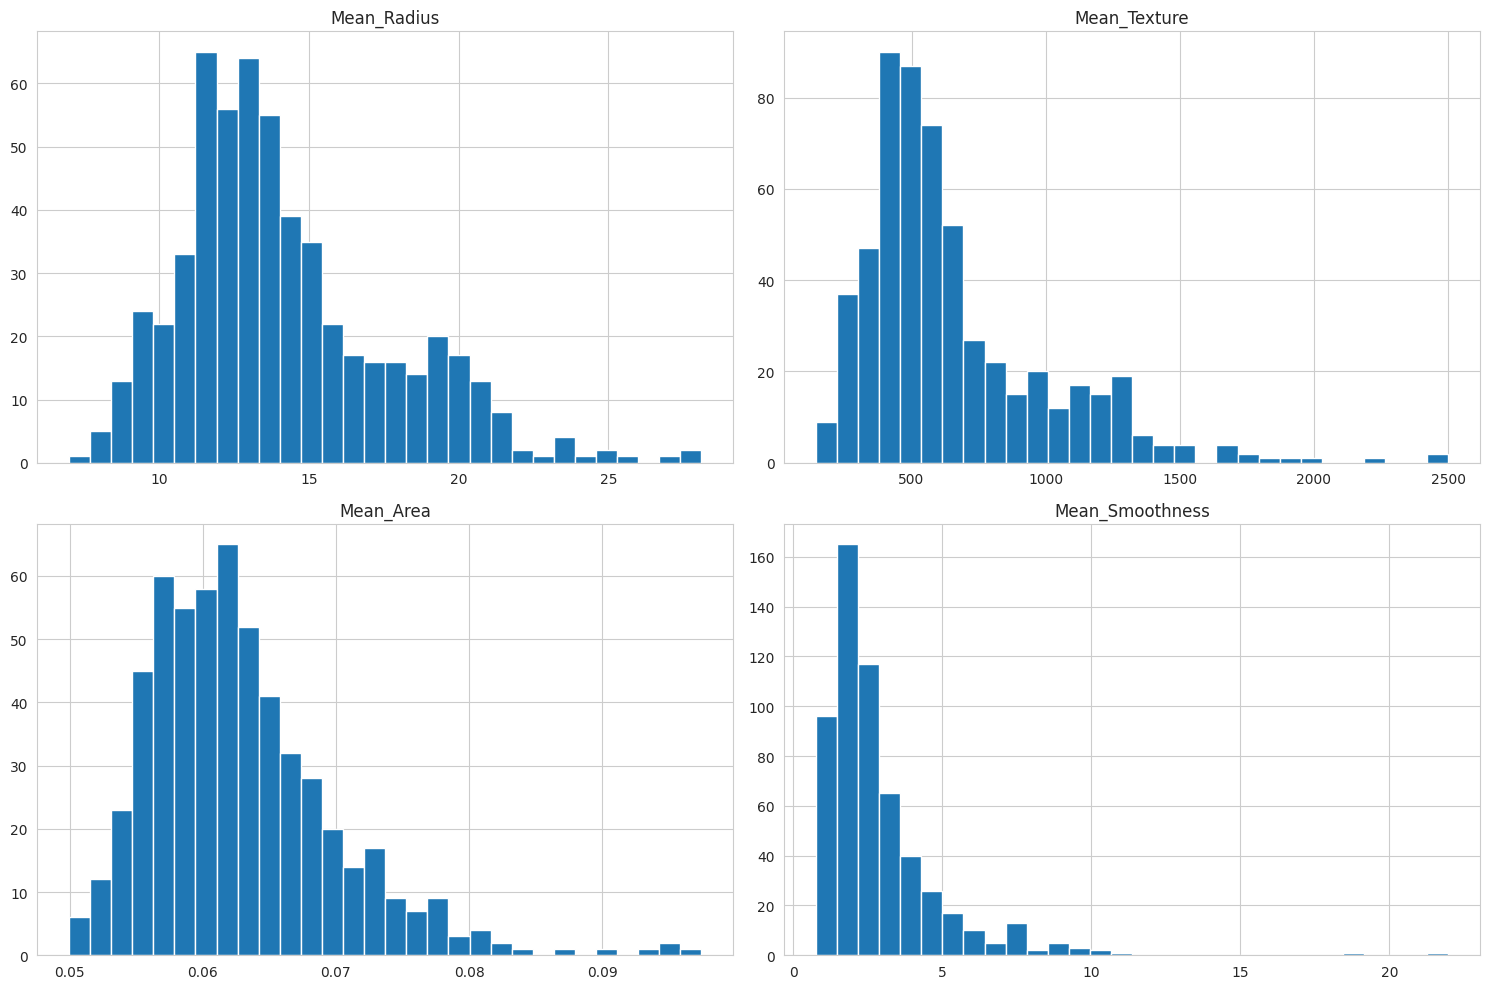

In [10]:
features_to_plot = ["Mean_Radius", "Mean_Texture", "Mean_Area", "Mean_Smoothness"]
df[features_to_plot].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

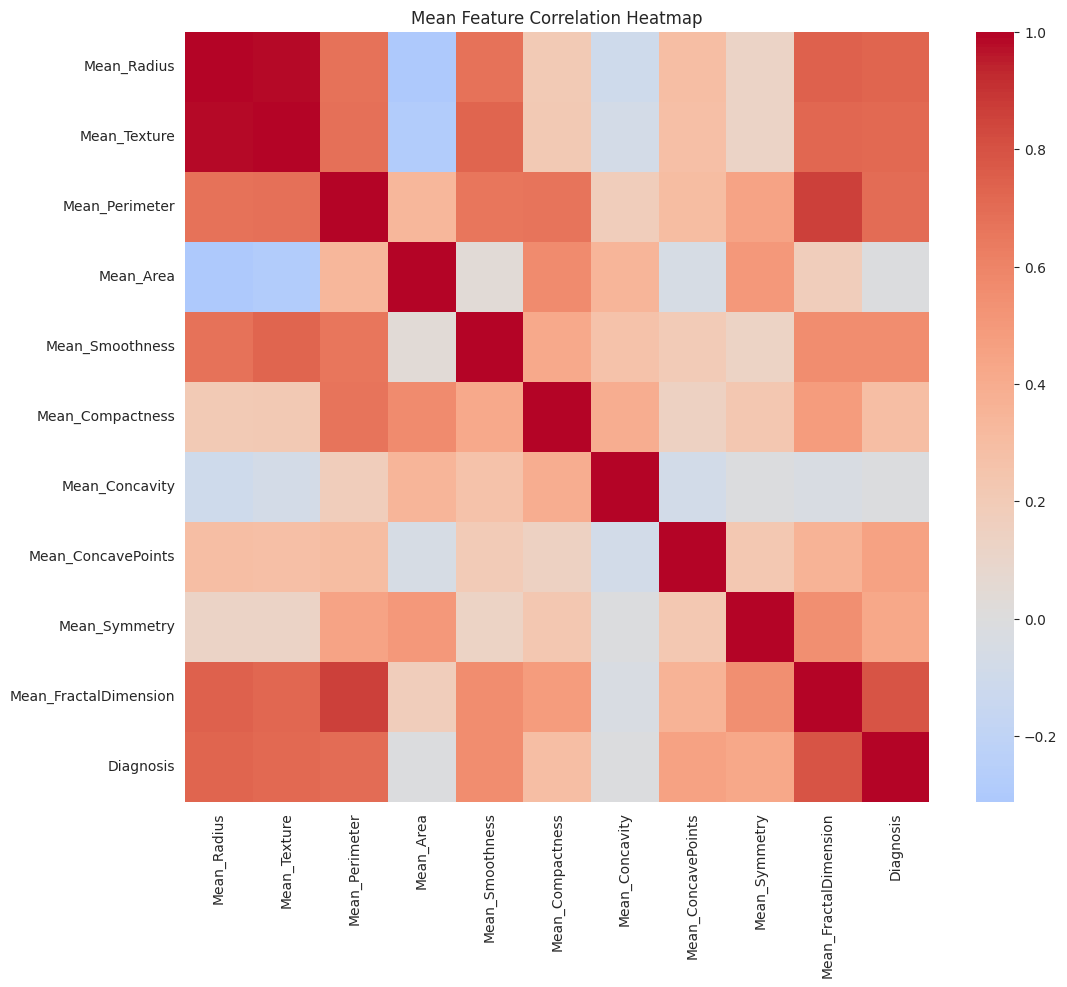

Top correlations with Diagnosis:
Diagnosis                 1.000000
Mean_FractalDimension     0.793566
SE_ConcavePoints          0.782914
SE_Perimeter              0.776614
Worst_Concavity           0.776454
Worst_Radius              0.742636
Worst_ConcavePoints       0.733825
Mean_Radius               0.730029
Mean_Texture              0.708984
Mean_Perimeter            0.696360
Worst_Symmetry            0.659610
Worst_Texture             0.596534
SE_Symmetry               0.590998
SE_Area                   0.567134
Mean_Smoothness           0.556141
SE_Smoothness             0.548236
Mean_ConcavePoints        0.456903
Mean_Symmetry             0.421465
SE_FractalDimension       0.416294
SE_Radius                 0.415185
Worst_Compactness         0.408042
SE_Texture                0.358560
Worst_Perimeter           0.330499
Worst_FractalDimension    0.323872
Mean_Compactness          0.292999
SE_Compactness            0.253730
SE_Concavity              0.077972
Mean_Concavity        

In [9]:
mean_features = [col for col in df.columns if col.startswith("Mean_")]

plt.figure(figsize=(12, 10))
sns.heatmap(df[mean_features + ["Diagnosis"]].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Mean Feature Correlation Heatmap")
plt.show()

target_corr = df.corr()["Diagnosis"].sort_values(ascending=False)
print("Top correlations with Diagnosis:")
print(target_corr)

### Feature Scaling

Many machine learning algorithms (SVR, linear models, neural networks) are sensitive to
the scale of input features. StandardScaler transforms each feature to have mean 0 and
standard deviation 1, which puts all features on equal footing.

Tree-based models (Random Forest, XGBoost) do not require scaling since they split on
thresholds independently of feature magnitude.

In [10]:
# === Executed Example: Feature Scaling ===
# Small inline dataset showing how StandardScaler transforms features
# to have mean ~0 and std ~1.

from sklearn.preprocessing import StandardScaler
import pandas as pd

data = pd.DataFrame({
    "Mean_Radius": [12.0, 13.5, 11.8, 17.2, 18.5],
    "Mean_Texture": [18.5, 20.2, 17.1, 21.4, 22.0],
    "Diagnosis": [0, 0, 0, 1, 1],
})

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[["Mean_Radius", "Mean_Texture"]])
scaled_df = pd.DataFrame(scaled_features, columns=["Mean_Radius_scaled", "Mean_Texture_scaled"])
scaled_df["Diagnosis"] = data["Diagnosis"]
print(scaled_df)
print(f"Means after scaling: {scaled_df[['Mean_Radius_scaled', 'Mean_Texture_scaled']].mean().values}")
print(f"Stds after scaling: {scaled_df[['Mean_Radius_scaled', 'Mean_Texture_scaled']].std().values}")

   Mean_Radius_scaled  Mean_Texture_scaled  Diagnosis
0           -0.945861            -0.736931          0
1           -0.400172             0.197982          0
2           -1.018620            -1.506860          0
3            0.945861             0.857920          1
4            1.418792             1.187890          1
Means after scaling: [ 8.8817842e-17 -8.8817842e-17]
Stds after scaling: [1.11803399 1.11803399]


In [11]:
from sklearn.preprocessing import StandardScaler

X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Mean after scaling (first 5 features): {X_scaled.mean(axis=0)[:5]}")
print(f"Std after scaling (first 5 features): {X_scaled.std(axis=0)[:5]}")
print(f"All means near zero: {np.allclose(X_scaled.mean(axis=0), 0, atol=1e-10)}")

Mean after scaling (first 5 features): [-1.37363271e-16  6.86816353e-17 -1.24875700e-16 -2.18532476e-16
 -8.36667193e-16]
Std after scaling (first 5 features): [1. 1. 1. 1. 1.]
All means near zero: True


### Feature Engineering

New features derived from existing columns can capture interactions and non-linear relationships.
Good candidates for breast cancer:
- **Ratio features**: `Mean_Radius / Mean_Perimeter` — tumor shape compactness
- **Interaction features**: `Mean_Radius × Mean_Concave_Points` — combined malignancy indicator
- **Area ratio**: `Worst_Area / Mean_Area` — growth rate proxy

Be careful with division by zero — add a small epsilon or +1 to the denominator.

#### Note

In pandas, you can create interaction features like this:

```python
df["feature1_feature2"] = df["feature1"] * df["feature2"]
```

In [12]:
# === Executed Example: Interaction Features ===
# Multiplication and ratio on a small inline dataset.

import pandas as pd

data = pd.DataFrame({
    "Mean_Radius": [12.0, 13.5, 11.8, 17.2, 18.5],
    "Mean_Perimeter": [78.5, 85.2, 74.1, 112.4, 120.0],
    "Mean_Concave_Points": [0.05, 0.08, 0.03, 0.15, 0.18],
})

data["Radius_Perimeter_Ratio"] = data["Mean_Radius"] / data["Mean_Perimeter"]
print("Radius / Perimeter ratio:\n", data[["Mean_Radius", "Mean_Perimeter", "Radius_Perimeter_Ratio"]])

data["Radius_Concavity"] = data["Mean_Radius"] * data["Mean_Concave_Points"]
print("\nRadius × Concavity:\n", data[["Mean_Radius", "Mean_Concave_Points", "Radius_Concavity"]])

Radius / Perimeter ratio:
    Mean_Radius  Mean_Perimeter  Radius_Perimeter_Ratio
0         12.0            78.5                0.152866
1         13.5            85.2                0.158451
2         11.8            74.1                0.159244
3         17.2           112.4                0.153025
4         18.5           120.0                0.154167

Radius × Concavity:
    Mean_Radius  Mean_Concave_Points  Radius_Concavity
0         12.0                 0.05             0.600
1         13.5                 0.08             1.080
2         11.8                 0.03             0.354
3         17.2                 0.15             2.580
4         18.5                 0.18             3.330


In [13]:
# === Commented Template: Interaction Features ===
# Uncomment and adapt to your own dataset.

# import pandas as pd
# data = pd.DataFrame({
#     "feature_a": [val1, val2, val3],
#     "feature_b": [val1, val2, val3],
# })
# data["a_times_b"] = data["feature_a"] * data["feature_b"]
# EPS = 1e-6
# data["a_over_b"] = data["feature_a"] / (data["feature_b"] + EPS)

In [16]:
EPS = 1e-6
df["Radius_Perimeter_Ratio"] = df["Mean_Radius"] / (df["Mean_Perimeter"] + EPS)
df["Texture_Radius_Ratio"] = df["Mean_Texture"] / (df["Mean_Radius"] + EPS)
df["Worst_to_Mean_Area"] = df["Worst_Area"] / (df["Mean_Area"] + EPS)
df["Worst_to_Mean_Radius"] = df["Worst_Radius"] / (df["Mean_Radius"] + EPS)

print("New feature statistics:")
print(df[["Radius_Perimeter_Ratio", "Texture_Radius_Ratio", "Worst_to_Mean_Area", "Worst_to_Mean_Radius"]].describe())

New feature statistics:
       Radius_Perimeter_Ratio  Texture_Radius_Ratio  Worst_to_Mean_Area  \
count            5.690000e+02            569.000000          569.000000   
mean             2.154954e+05             43.583390           19.452995   
std              1.424949e+06             11.160170            8.744607   
min              2.368787e+01             20.555791            5.904821   
25%              1.214134e+02             35.892397           13.360835   
50%              2.111759e+02             41.175581           17.719510   
75%              4.212256e+02             49.482218           23.589452   
max              1.227000e+07             91.210792           75.770501   

       Worst_to_Mean_Radius  
count            569.000000  
mean               6.489890  
std                0.131440  
min                6.175257  
25%                6.391950  
50%                6.468895  
75%                6.562342  
max                7.120911  


In [15]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(PROCESSED_DIR / "engineered_data.csv", index=False)
print("Engineered data saved to data/processed/engineered_data.csv")

Engineered data saved to data/processed/engineered_data.csv


### Exercises

1. **Try different scalers**: Replace `StandardScaler` with `MinMaxScaler` or `RobustScaler` and compare how the scaled distributions look.
2. **Identify redundant features**: Find pairs of features with correlation > 0.95. Would dropping one affect model performance?
3. **Create a mean-to-se ratio**: For each Mean_ feature, create a corresponding `Mean_to_SE` ratio (e.g., `df["Radius_Mean_to_SE"] = df["Mean_Radius"] / (df["Radius_SE"] + 1e-6)`). Does this capture measurement reliability?
4. **Log transform skewed features**: Some features like `Area` may be right-skewed. Try `np.log1p()` and check if the distribution becomes more normal.
5. **Pairplot**: Use `sns.pairplot()` on a subset of the most discriminative features, coloring by Diagnosis — do benign and malignant samples form distinct clusters?